## Correct Target
Simulation of environment under the correct syndrome extraction circuits in order to find out if target state is correct

In [1]:
import numpy as np

import sys

sys.path.append(r'../')
from rlftqc.simulators.clifford_gates import CliffordGates

%load_ext autoreload
%autoreload 2
%matplotlib inline

from rlftqc.envs.logical_state_preparation_env import LogicalStatePreparationEnv
from rlftqc.envs.wrappers.tableau_to_grid_wrapper import TableauToGridWrapper
from rlftqc.envs.cells import build_cells, get_mapping, get_target
from rlftqc.logical_state_preparation import LogicalStatePreparation

target = get_target()

print(f"len(target): {len(target)}")

cliff_gates = CliffordGates(17)

cells_from_helper = build_cells()
mapping = get_mapping()
# These are location masks; the environment expands them for every gate.
action_mask = np.asarray([cell.action_mask for cell in cells_from_helper], dtype=bool)

gates = [cliff_gates.h, cliff_gates.cx, cliff_gates.cz]
lsp = LogicalStatePreparation(target, gates=gates, cells=cells_from_helper, action_mask=action_mask, mapping=mapping)




[[0 1]
 [0 2]
 [1 1]
 [1 2]
 [1 3]
 [1 4]
 [2 0]
 [2 1]
 [2 2]
 [2 3]
 [2 4]
 [3 0]
 [3 1]
 [3 2]
 [3 3]
 [4 2]
 [4 3]]
index_grid:
 [[-1  0  1 -1 -1]
 [-1  2  3  4  5]
 [ 6  7  8  9 10]
 [11 12 13 14 -1]
 [-1 -1 15 16 -1]]
mapping: [[0 1]
 [0 2]
 [1 1]
 [1 2]
 [1 3]
 [1 4]
 [2 0]
 [2 1]
 [2 2]
 [2 3]
 [2 4]
 [3 0]
 [3 1]
 [3 2]
 [3 3]
 [4 2]
 [4 3]]
target_cells: [Cell(cell_type='bulk', measure_qubit=3, data_qubits=Neighbors(north=1, east=4, south=8, west=2), action_mask=(True, True, True, True, True)), Cell(cell_type='bulk', measure_qubit=7, data_qubits=Neighbors(north=2, east=8, south=12, west=6), action_mask=(True, True, True, True, True)), Cell(cell_type='bulk', measure_qubit=9, data_qubits=Neighbors(north=4, east=10, south=14, west=8), action_mask=(True, True, True, True, True)), Cell(cell_type='bulk', measure_qubit=13, data_qubits=Neighbors(north=8, east=14, south=15, west=12), action_mask=(True, True, True, True, True)), Cell(cell_type='boundary', measure_qubit=0, data_qubits=N

/Users/shakeebmajid/dev/magiqware/rlftqc-biased-noise/.venv312/lib/python3.12/site-packages/jax/_src/ops/scatter.py:108: FutureWarning: scatter inputs have incompatible types: cannot safely cast value from dtype=int32 to dtype=uint8 with jax_numpy_dtype_promotion='standard'. In future JAX releases this will result in an error.
  warnings.warn(


In [2]:
import jax
import jax.numpy as jnp

# Recreate the environment so an earlier five-column override cannot survive.
import importlib
env_module = importlib.import_module("rlftqc.envs.logical_state_preparation_env")
importlib.reload(env_module)
previous_env = lsp.env
env = env_module.LogicalStatePreparationEnv(
    target=previous_env.target,
    gates=previous_env.gates,
    graph=previous_env.graph,
    distance_metric=previous_env.distance_metric,
    max_steps=previous_env.max_steps,
    threshold=previous_env.threshold,
    initialize_plus=previous_env.initialize_plus,
    use_max_reward=previous_env.use_max_reward,
    cells=cells_from_helper,
)
lsp.env = env
assert env.action_map.shape == (len(env.cells), env.num_candidates)

# Keep every gate/location choice generated by the environment.
# Look up the extraction schedule by name rather than numbered slots.
candidate_indices = {candidate: i for i, candidate in enumerate(env.action_candidates)}
xzzx_schedule = (
    ("h", "center"),
    ("cx", "south"),
    ("cz", "west"),
    ("cz", "east"),
    ("cx", "north"),
    ("h", "center"),
)
xzzx_choices = [candidate_indices[candidate] for candidate in xzzx_schedule]
xzzx_actions = jnp.asarray([
    [choice] * len(cells_from_helper) for choice in xzzx_choices
], dtype=jnp.int32)
print(f"Full gate/location map shape: {env.action_map.shape}")
print(f"Candidates: {env.action_candidates}")
print(f"Action map:\n{env.action_map}")
print(f"Action vectors:\n{xzzx_actions}")


Full gate/location map shape: (8, 9)
Candidates: (('h', 'center'), ('cx', 'north'), ('cx', 'east'), ('cx', 'south'), ('cx', 'west'), ('cz', 'north'), ('cz', 'east'), ('cz', 'south'), ('cz', 'west'))
Action map:
[[ 0  1  2  3  4  5  6  7  8]
 [ 9 10 11 12 13 14 15 16 17]
 [18 19 20 21 22 23 24 25 26]
 [27 28 29 30 31 32 33 34 35]
 [36 -1 37 38 -1 -1 39 40 -1]
 [41 -1 -1 42 43 -1 -1 44 45]
 [46 47 -1 -1 48 49 -1 -1 50]
 [51 52 53 -1 -1 54 55 -1 -1]]
Action vectors:
[[0 0 0 0 0 0 0 0]
 [3 3 3 3 3 3 3 3]
 [8 8 8 8 8 8 8 8]
 [6 6 6 6 6 6 6 6]
 [1 1 1 1 1 1 1 1]
 [0 0 0 0 0 0 0 0]]


## Which actions are mapped?
This report checks every available choice, explains missing boundary directions, and checks that every registered gate can be selected.

In [3]:
from html import escape
from IPython.display import HTML, display

# Show and validate every gate/location choice for every cell.
map_values = np.asarray(env.action_map)
headers = "".join(
    f"<th>Choice {choice}<br>{escape(gate.upper())}<br>{escape(location)}</th>"
    for choice, (gate, location) in enumerate(env.action_candidates)
)
rows = []
mapping_errors = []
reachable = set()
mapped_count = skipped_count = 0
for i, cell in enumerate(env.cells):
    entries = []
    for choice, (gate, location) in enumerate(env.action_candidates):
        location_index = env.candidate_location_indices[choice]
        neighbor = None if location == "center" else getattr(cell.data_qubits, location)
        enabled = bool(cell.action_mask[location_index])
        available = enabled and (location == "center" or neighbor is not None)
        index = int(map_values[i, choice])
        args = str(cell.measure_qubit)
        if location != "center" and neighbor is not None:
            args += f", {neighbor}"
        expected = f".{gate}({args})"
        actual = env.action_string[index] if 0 <= index < len(env.actions) else None
        if 0 <= index < len(env.actions):
            reachable.add(index)

        if available and actual == expected:
            mapped_count += 1
            color = "#ecfdf5"
            text = f"✓ {escape(actual[1:].upper())}<br><small>Global #{index}</small>"
        elif not available and index == -1:
            skipped_count += 1
            color = "#fff7ed"
            reason = "No neighbor" if location != "center" and neighbor is None else "Location disabled"
            text = f"Skipped<br><small>{reason} · -1</small>"
        else:
            color = "#fef2f2"
            reason = f"Expected {expected}" if available else "Expected -1 (unavailable)"
            text = f"Mismatch<br><small>{escape(reason)}<br>Got {escape(str(actual))} · #{index}</small>"
            mapping_errors.append(f"Cell {i}, choice {choice}: {reason}; got {actual} at {index}")
        entries.append(f'<td style="background:{color}">{text}</td>')
    rows.append(
        f"<tr><th>Cell {i}<br>{escape(cell.cell_type)}<br>Measure q{cell.measure_qubit}</th>"
        + "".join(entries) + "</tr>"
    )

unmapped_actions = sorted(set(range(len(env.actions))) - reachable)
if unmapped_actions:
    mapping_errors.append(f"Registered gates with no map entry: {unmapped_actions}")
summary = (
    f"{mapped_count} choices mapped correctly · {skipped_count} unavailable choices skipped · "
    f"{len(reachable)}/{len(env.actions)} registered gates reachable"
)
status = "All mappings checked successfully." if not mapping_errors else "Mapping problems found."
issues = "" if not mapping_errors else "<ul>" + "".join(
    f"<li>{escape(error)}</li>" for error in mapping_errors
) + "</ul>"
mapping_report = HTML(
    '<style>.gate-map {border-collapse:collapse;font-size:12px}'
    '.gate-map th,.gate-map td {border:1px solid #cbd5e1;padding:10px;text-align:center;color:#172033}'
    '.gate-map th {background:#f1f5f9}.gate-map small {font-size:11px}</style>'
    f'<p><b>{status}</b><br>{summary}</p>'
    '<p>Columns are the agent’s local choices. Each green entry shows the actual gate '
    'and its global index in <code>env.actions</code>. Orange entries explain boundary skips. '
    'Red entries indicate an incorrect mapping. Each entry is checked against its cell’s qubits.</p>'
    '<div style="overflow-x:auto"><table class="gate-map"><thead><tr><th>Cell</th>'
    + headers + '</tr></thead><tbody>' + "".join(rows) + '</tbody></table></div>' + issues
)
display(mapping_report)


Cell,Choice 0Hcenter,Choice 1CXnorth,Choice 2CXeast,Choice 3CXsouth,Choice 4CXwest,Choice 5CZnorth,Choice 6CZeast,Choice 7CZsouth,Choice 8CZwest
Cell 0bulkMeasure q3,✓ H(3)Global #0,"✓ CX(3, 1)Global #1","✓ CX(3, 4)Global #2","✓ CX(3, 8)Global #3","✓ CX(3, 2)Global #4","✓ CZ(3, 1)Global #5","✓ CZ(3, 4)Global #6","✓ CZ(3, 8)Global #7","✓ CZ(3, 2)Global #8"
Cell 1bulkMeasure q7,✓ H(7)Global #9,"✓ CX(7, 2)Global #10","✓ CX(7, 8)Global #11","✓ CX(7, 12)Global #12","✓ CX(7, 6)Global #13","✓ CZ(7, 2)Global #14","✓ CZ(7, 8)Global #15","✓ CZ(7, 12)Global #16","✓ CZ(7, 6)Global #17"
Cell 2bulkMeasure q9,✓ H(9)Global #18,"✓ CX(9, 4)Global #19","✓ CX(9, 10)Global #20","✓ CX(9, 14)Global #21","✓ CX(9, 8)Global #22","✓ CZ(9, 4)Global #23","✓ CZ(9, 10)Global #24","✓ CZ(9, 14)Global #25","✓ CZ(9, 8)Global #26"
Cell 3bulkMeasure q13,✓ H(13)Global #27,"✓ CX(13, 8)Global #28","✓ CX(13, 14)Global #29","✓ CX(13, 15)Global #30","✓ CX(13, 12)Global #31","✓ CZ(13, 8)Global #32","✓ CZ(13, 14)Global #33","✓ CZ(13, 15)Global #34","✓ CZ(13, 12)Global #35"
Cell 4boundaryMeasure q0,✓ H(0)Global #36,SkippedNo neighbor · -1,"✓ CX(0, 1)Global #37","✓ CX(0, 2)Global #38",SkippedNo neighbor · -1,SkippedNo neighbor · -1,"✓ CZ(0, 1)Global #39","✓ CZ(0, 2)Global #40",SkippedNo neighbor · -1
Cell 5boundaryMeasure q5,✓ H(5)Global #41,SkippedNo neighbor · -1,SkippedNo neighbor · -1,"✓ CX(5, 10)Global #42","✓ CX(5, 4)Global #43",SkippedNo neighbor · -1,SkippedNo neighbor · -1,"✓ CZ(5, 10)Global #44","✓ CZ(5, 4)Global #45"
Cell 6boundaryMeasure q16,✓ H(16)Global #46,"✓ CX(16, 14)Global #47",SkippedNo neighbor · -1,SkippedNo neighbor · -1,"✓ CX(16, 15)Global #48","✓ CZ(16, 14)Global #49",SkippedNo neighbor · -1,SkippedNo neighbor · -1,"✓ CZ(16, 15)Global #50"
Cell 7boundaryMeasure q11,✓ H(11)Global #51,"✓ CX(11, 6)Global #52","✓ CX(11, 12)Global #53",SkippedNo neighbor · -1,SkippedNo neighbor · -1,"✓ CZ(11, 6)Global #54","✓ CZ(11, 12)Global #55",SkippedNo neighbor · -1,SkippedNo neighbor · -1


In [4]:
key = jax.random.PRNGKey(0)
params = env.default_params
obs, state = env.reset_env(key, params)
xzzx_distances = []
xzzx_gate_history = []

# step_env translates each vector through action_map and applies the gates.
# Use it directly so an early done flag does not auto-reset this target check.
for label, action in zip(("H", "CX south", "CZ west", "CZ east", "CX north", "H"), xzzx_actions):
    # Record the exact gates selected by action_map for this step.
    global_actions = np.asarray(env.action_map)[
        np.arange(len(cells_from_helper)), np.asarray(action)
    ]
    selected_gates = [
        {"cell": i, "choice": int(choice), "gate": None if index < 0 else env.action_string[int(index)]}
        for i, (choice, index) in enumerate(zip(np.asarray(action), global_actions))
    ]
    key, step_key = jax.random.split(key)
    obs, state, reward, done, info = env.step_env(step_key, state, action, params)
    xzzx_distances.append(float(state.previous_distance))
    xzzx_gate_history.append({"label": label, "gates": selected_gates})
    print(f"After {label}: target similarity = {float(state.previous_distance):.6f}")

print(f"Final target similarity: {float(state.previous_distance):.6f}")


obs_tab: (17, 34), obs_sign: (17,)
obs_tab: (17, 34), obs_sign: (17,)
After H: target similarity = 0.018868
obs_tab: (17, 34), obs_sign: (17,)
After CX south: target similarity = 0.157895
obs_tab: (17, 34), obs_sign: (17,)
After CZ west: target similarity = 0.111111
obs_tab: (17, 34), obs_sign: (17,)
After CZ east: target similarity = 0.086957
obs_tab: (17, 34), obs_sign: (17,)
After CX north: target similarity = 0.076923
obs_tab: (17, 34), obs_sign: (17,)
After H: target similarity = 0.065217
Final target similarity: 0.065217


## Gates added at each step
The plots use the gates recorded from `action_map` during execution. Missing boundary neighbors are listed as skipped cells.

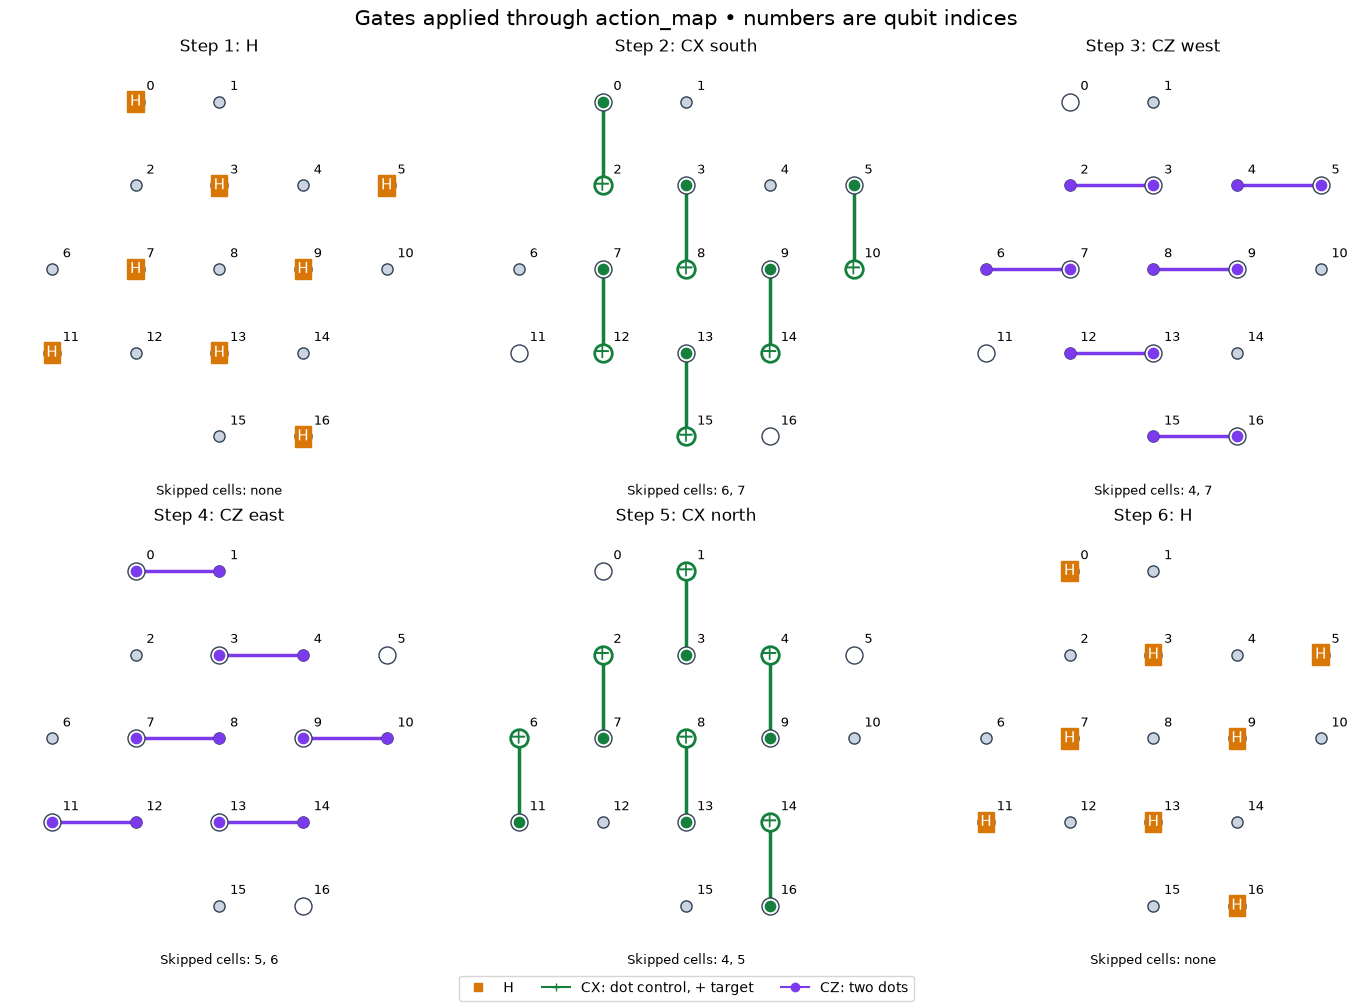

In [5]:
import re
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


def plot_gate_step(step, ax=None):
    """Draw one completed step (1-based) from the recorded action map."""
    if not 1 <= step <= len(xzzx_gate_history):
        raise ValueError(f"step must be between 1 and {len(xzzx_gate_history)}")
    if ax is None:
        _, ax = plt.subplots(figsize=(6, 6))
    record = xzzx_gate_history[step - 1]
    positions = np.asarray(mapping)
    measurement_qubits = {int(cell.measure_qubit) for cell in cells_from_helper}
    colors = {"h": "#d97706", "cx": "#15803d", "cz": "#7c3aed"}

    # Grid coordinates match the notebook's lattice, with north at the top.
    for qubit, (row, col) in enumerate(positions):
        is_measurement = qubit in measurement_qubits
        ax.scatter(col, row, s=150 if is_measurement else 65,
                   facecolors="white" if is_measurement else "#cbd5e1",
                   edgecolors="#334155", zorder=3)
        ax.text(col + 0.13, row - 0.14, str(qubit), fontsize=9, zorder=6)

    skipped = []
    for selection in record["gates"]:
        gate = selection["gate"]
        if gate is None:
            skipped.append(str(selection["cell"]))
            continue
        match = re.fullmatch(r"\.(h|cx|cz)\((\d+)(?:, (\d+))?\)", gate)
        if match is None:
            raise ValueError(f"Unsupported gate in action map: {gate}")
        name, control, target_qubit = match.groups()
        row, col = positions[int(control)]
        color = colors[name]
        if name == "h":
            ax.text(col, row, "H", ha="center", va="center", color="white",
                    fontsize=11, bbox=dict(boxstyle="square,pad=0.18", fc=color, ec=color), zorder=5)
        else:
            target_row, target_col = positions[int(target_qubit)]
            ax.plot([col, target_col], [row, target_row], color=color, lw=2.5, zorder=2)
            ax.scatter(col, row, s=55, color=color, zorder=5)
            if name == "cx":
                ax.scatter(target_col, target_row, s=160, facecolors="white",
                           edgecolors=color, linewidths=2, zorder=4)
                ax.text(target_col, target_row, "+", color=color, fontsize=15,
                        ha="center", va="center", zorder=5)
            else:
                ax.scatter(target_col, target_row, s=55, color=color, zorder=5)

    ax.set_title(f"Step {step}: {record['label']}", fontsize=12)
    ax.set_xlim(-0.5, positions[:, 1].max() + 0.5)
    ax.set_ylim(positions[:, 0].max() + 0.5, -0.5)
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_xlabel("Skipped cells: " + (", ".join(skipped) if skipped else "none"), fontsize=9)
    return ax


# Each panel shows only the gates added in that step, not accumulated gates.
fig, axes = plt.subplots(2, 3, figsize=(14, 10), constrained_layout=True)
for step, ax in enumerate(axes.flat, start=1):
    if step <= len(xzzx_gate_history):
        plot_gate_step(step, ax)
    else:
        ax.set_visible(False)
fig.suptitle("Gates applied through action_map • numbers are qubit indices", fontsize=15)
fig.legend(handles=[
    Line2D([], [], marker="s", color="#d97706", linestyle="none", label="H"),
    Line2D([], [], color="#15803d", marker="+", label="CX: dot control, + target"),
    Line2D([], [], color="#7c3aed", marker="o", label="CZ: two dots"),
], loc="outside lower center", ncol=3)
plt.show()

# For a larger view of one step, run: plot_gate_step(3); plt.show()
